[Home](../../README.md)

### Data Wrangling

This is a demonstration of data wrangling using [Pandas](https://pandas.pydata.org/) the library for data analysis and manipulation.

This Jupyter Notepad demonstrates different processes you can apply to your data to prepare it for feature engineering and model training. For this demonstration we will wrangle the diabetes data set you previewed in the last Jupyter Notebook.

> [!Note]
> None of these processes are destructive to the source CSV as long as you save the modified data to a new CSV.

#### Load the required dependencies

In [1]:
# Import frameworks
import pandas as pd
import matplotlib.pyplot as plt

####  Store the data as a local variable

The data frame is a Pandas object that structures your tabular data into an appropriate format. It loads the complete data in memory so it is now ready for preprocessing.

In [2]:
data_frame = pd.read_csv("spotify_songs.csv")

####  Drop irrelevant columns

The data frame is a Pandas object that structures your tabular data into an appropriate format. It loads the complete data in memory so it is now ready for preprocessing. (fix later)

In [3]:
data_frame.columns


Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='str')

In [4]:
to_drop = [
    "track_id",
    "track_name",
    "track_artist",
    "track_album_id",
    "track_album_name",
    "playlist_name",
    "playlist_id",
    "playlist_genre",
    "playlist_subgenre"
]

print(to_drop)

all_to_drop = [i for i in to_drop if i in data_frame.columns]

data_frame = data_frame.drop(columns=all_to_drop)

print(data_frame.columns)

['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre']
Index(['track_popularity', 'track_album_release_date', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'],
      dtype='str')


In [5]:
data_frame = data_frame.rename(columns={"mode": "song_mode"})
data_frame.columns

Index(['track_popularity', 'track_album_release_date', 'danceability',
       'energy', 'key', 'loudness', 'song_mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'],
      dtype='str')

In [6]:
data_frame.song_mode.unique()

array([1, 0])

#### Dealing with null values

Null values during data analysis can cause runtime errors and unexpected results. It is important to identify null values and deal with them appropriately before training a model.

The `isnull().sum()` method call returns the null values in any column.

In [7]:
data_frame.isnull().sum()

track_popularity            0
track_album_release_date    0
danceability                0
energy                      0
key                         0
loudness                    0
song_mode                   0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

If you have null data there are many ways to deal with the empty/null values. These are the two most common approaches.
1. Remove any row with a null value with a `dropna()` method call.
2. Replace missing values with another value with a `fillna()` method call. Generally, we use mean value for numerical columns because it may cause minimal changes in your mathematical analysis while maintaining the original size of the data.

Students should reflect why this example removes the null 'SEX' but replacing the mean 'Target'?

In [ ]:
# Remove Null values
#data_frame = data_frame.dropna(subset=['SEX'])
#data_frame.isnull().sum()

In [ ]:
# Replace Null values with the mean value for the column
#data_frame['Target'] = data_frame['Target'].fillna(data_frame['Target'].mean())
#data_frame.isnull().sum()

#### Remove Duplicates

Duplicate data can have detrimental effects on your machine learning models and outcomes, such as reducing data diversity and representativeness, which can lead to overfitting or biased models.

The `duplicated().sum()` method call returns the count of duplicate rows in the data frame.

In [8]:
data_frame.duplicated().sum()

np.int64(4485)

In [9]:
duplicate_mask = data_frame.duplicated()
print(data_frame.loc[duplicate_mask])

       track_popularity track_album_release_date  danceability  energy  key  \
1299                 93               2019-10-23         0.505   0.340    4   
1300                 98               2019-09-20         0.764   0.320   11   
1304                 94               2019-05-17         0.501   0.405    1   
1305                 88               2019-06-19         0.759   0.548    9   
1307                 96               2019-10-12         0.721   0.716   10   
...                 ...                      ...           ...     ...  ...   
32783                64               2014-02-25         0.606   0.720    5   
32793                52               2014-01-01         0.496   0.789    1   
32798                67               2011-05-13         0.507   0.665    0   
32804                 1               2013-10-22         0.479   0.675    9   
32808                54               2012-12-29         0.712   0.497   11   

       loudness  song_mode  speechiness  acousticne

The `drop_duplicates()` method call can be then stored back onto the data_frame variable removing the duplicates.

In [10]:
data_frame = data_frame.drop_duplicates()
data_frame.duplicated().sum()

np.int64(0)

In [11]:
data_frame.info()

<class 'pandas.DataFrame'>
Index: 28348 entries, 0 to 32832
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_popularity          28348 non-null  int64  
 1   track_album_release_date  28348 non-null  str    
 2   danceability              28348 non-null  float64
 3   energy                    28348 non-null  float64
 4   key                       28348 non-null  int64  
 5   loudness                  28348 non-null  float64
 6   song_mode                 28348 non-null  int64  
 7   speechiness               28348 non-null  float64
 8   acousticness              28348 non-null  float64
 9   instrumentalness          28348 non-null  float64
 10  liveness                  28348 non-null  float64
 11  valence                   28348 non-null  float64
 12  tempo                     28348 non-null  float64
 13  duration_ms               28348 non-null  int64  
dtypes: float64(9), int64(4

In [12]:
data_frame["track_album_release_date"] = pd.to_datetime(
    data_frame["track_album_release_date"], format="mixed"
).dt.year

data_frame["track_album_release_date"] = (
    data_frame["track_album_release_date"]
    .fillna(data_frame["track_album_release_date"].mean())
    .astype(int)
)

print(data_frame["track_album_release_date"].unique())
print(data_frame["track_album_release_date"].info())

[2019 2018 2017 2016 2014 2012 2015 2013 2011 2010 2008 2020 2007 1998
 1996 1999 2009 1993 1995 1991 2000 1994 1992 1997 2001 2006 2002 2003
 2005 1990 2004 1988 1984 1982 1973 1979 1977 1981 1974 1970 1976 1987
 1978 1969 1986 1980 1983 1985 1989 1975 1968 1971 1972 1967 1966 1965
 1964 1963 1962 1957 1958 1961 1960]
<class 'pandas.Series'>
Index: 28348 entries, 0 to 32832
Series name: track_album_release_date
Non-Null Count  Dtype
--------------  -----
28348 non-null  int64
dtypes: int64(1)
memory usage: 442.9 KB
None


#### Replace data

We can run a lambda function on a column to modify its values. For a simple example, let’s convert the Sex to lowercase. To run a function over a complete column, we can use the apply method which iterates over each row and modifies the values.

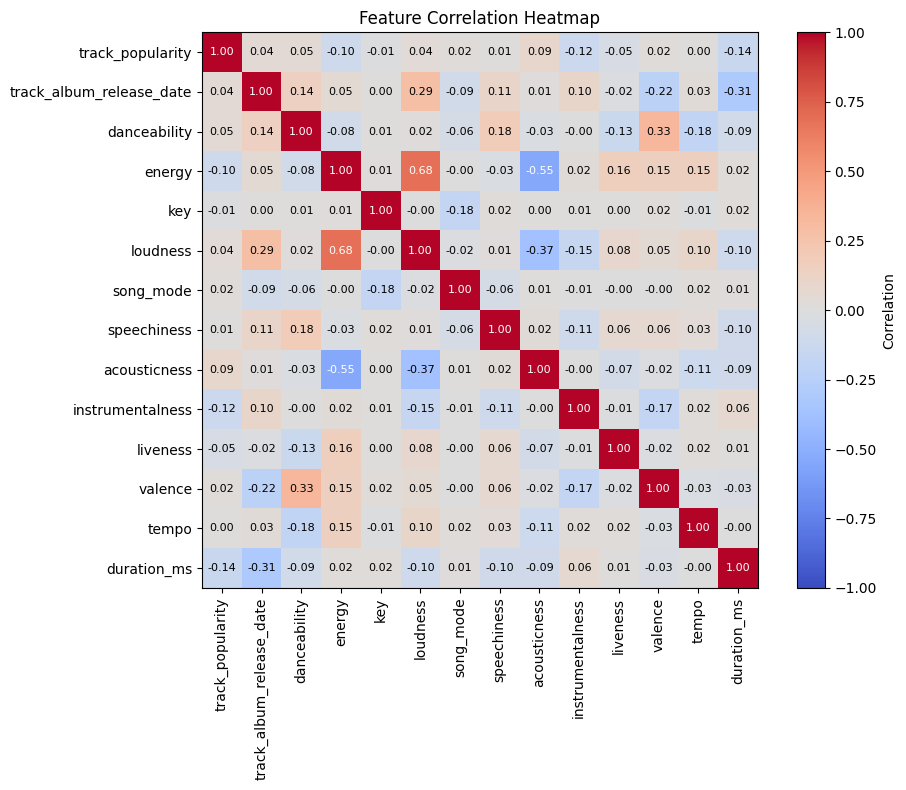

In [13]:
corr = data_frame.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        text_color = "white" if abs(value) > 0.5 else "black"
        plt.text(
            j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8
        )
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

We can check that there are no data entry errors by the `unique()` method call.

#### Remove outliers

Outliers can skew your analysis on numerical columns, and it is important to remove them. We can use the 25th and 75th quartile on numerical data, to get the inter-quartile range. This allows us to estimate an acceptable range, and we can then filter out any values outside this range. Mathematically, outliers are values occurring outside 1.5 times the interquartile range (IQR) from the first quartile (Q1) or third quartile (Q3).

In [14]:
# Get the inter-quartile range for all numerical columns
numerical_cols = data_frame.select_dtypes(include="number").columns

for col in numerical_cols:
    Q1 = data_frame[col].quantile(0.25)
    Q3 = data_frame[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - IQR * 1.5
    upper_bound = Q3 + IQR * 1.5
    outlier_count = (
        (data_frame[col] < lower_bound) | (data_frame[col] > upper_bound)
    ).sum()
    print(f"\n{col}:")
    print(f"  Outliers are above {upper_bound:.4f} or below {lower_bound:.4f}")
    print(f"  Number of outliers: {outlier_count}")
# ...existing code...


track_popularity:
  Outliers are above 113.5000 or below -34.5000
  Number of outliers: 0

track_album_release_date:
  Outliers are above 2035.5000 or below 1991.5000
  Number of outliers: 2354

danceability:
  Outliers are above 1.0585 or below 0.2625
  Number of outliers: 257

energy:
  Outliers are above 1.2390 or below 0.1830
  Number of outliers: 222

key:
  Outliers are above 19.5000 or below -8.5000
  Number of outliers: 0

loudness:
  Outliers are above 0.6940 or below -13.7140
  Number of outliers: 837

song_mode:
  Outliers are above 2.5000 or below -1.5000
  Number of outliers: 0

speechiness:
  Outliers are above 0.2710 or below -0.0970
  Number of outliers: 2725

acousticness:
  Outliers are above 0.6284 or below -0.3540
  Number of outliers: 1911

instrumentalness:
  Outliers are above 0.0164 or below -0.0098
  Number of outliers: 6082

liveness:
  Outliers are above 0.4836 or below -0.1420
  Number of outliers: 1623

valence:
  Outliers are above 1.2440 or below -0.2200

In [ ]:
# Filter all numerical columns within the acceptable range
for col in numerical_cols:
    Q1 = data_frame[col].quantile(0.25)
    Q3 = data_frame[col].quantile(0.75)
    IQR = Q3 - Q1
    data_frame = data_frame[
        (data_frame[col] >= Q1 - 1.5 * IQR) & (data_frame[col] <= Q3 + 1.5 * IQR)
    ]

print(f"Rows remaining after outlier removal: {len(data_frame)}")
print(data_frame.describe())
# ...existing code...

#### Scaling features to a common range

Scaling the features makes it easier for machine learning algorithms to find the optimal solution, as the different scales of the features do not influence them.

In [ ]:
#scale_feature = 'BP'

#the minimum value with space for outliers
#MIN_BP = 55

#the maximum value with space for outliers
#MAX_BP = 140

#scale features
#data_frame[scale_feature] = [(X - MIN_BP) / (MAX_BP - MIN_BP) for X in data_frame[scale_feature]]

#data_frame.describe()

> [!important]
> You need to save the calculations for each dataset you scale for scaling new values for prediction. Use [2.1.2.data.records.md](2.1.2.data.records.md) to record this information.

#### Save the wrangled data to CSV

In [ ]:
data_frame.to_csv('../2.2.Feature_Engineering/wrangled_data.csv', index=False)